In [1]:
### STEP 1: IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
from PIL import Image

# Set working directory if needed (optional)
os.chdir("W:/Project/MPI_Registration/Proj01") # Select a directory 

# Define directories
r_dir = 'results/r_output/'
#r_dir = 'results/plots/'
out_dir = 'results/py_output/'
ref_dir = 'data/reference/'

# Define slice names (same as in R script)
paths = ["ABCA7-5-a1-7", "BIN1-5-a3-8"]  # <- update here for each slide

# Load Visium query images and landmarks
query_images = [cv2.imread(os.path.join(r_dir, f"{path}_hires_image.png")) for path in paths]
query_landmarks = pd.read_csv(os.path.join(r_dir, "Query_Reference_Landmarks_for_Visium_Data.csv"), index_col=[0, 1])

# Load reference image and landmarks
reference_image = cv2.imread(os.path.join(ref_dir, "40x_Wt-317-a4_6mo_(1)_Visium_2A_nl.png"))
reference_image = cv2.cvtColor(reference_image, cv2.COLOR_BGR2RGB)
reference_landmarks = pd.read_csv(os.path.join(r_dir, "Reference_Landmarks_for_Spatial_Registration.csv"), index_col=[0, 1])

# Store samples
samples = paths


In [2]:
# Functions that perform the alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    # keep only coordinate columns
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # want reference coords to have full complement
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1])

    # keep only shared landmarks
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    return cv2.findHomography(query_coords, reference_coords, method = 0)[0], (reference_coords, query_coords)
 

def transform_points(points, mat):
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)

# Function for dealing with image dimension syntax
def Reverse(tuples):
    new_tup = tuples[::-1]
    return new_tup

In [3]:
# STEP 2 - Image alignment and transformations

# Note even though our reference is the reference image manually annotated, we technically treat the query images as a reference, 
# since we map the reference image onto the Visium images
temp = [calculate_homography_matrix(reference_coords = query_landmarks.iloc[(2*i):(2*i+2),:],
                                    query_coords=reference_landmarks) 
        for i in list(range(len(query_images)))]

mats, coord_sets = zip(*temp)

# Transform reference images + landmarks into Visium space space
images_transformed = [cv2.warpPerspective(reference_image, mat, Reverse(img.shape)[1:3]) for img, mat in zip(query_images, mats)]
landmarks_transformed = [transform_points(landmark, mat) for (_, landmark), mat in zip(coord_sets, mats)]

nrow = len(query_images)
n_features = 16

C:\Users\wjd4002\AppData\Local\Temp\ipykernel_28684\2497027725.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(reference_landmarks.iloc[0,:].filter(regex='V').values,


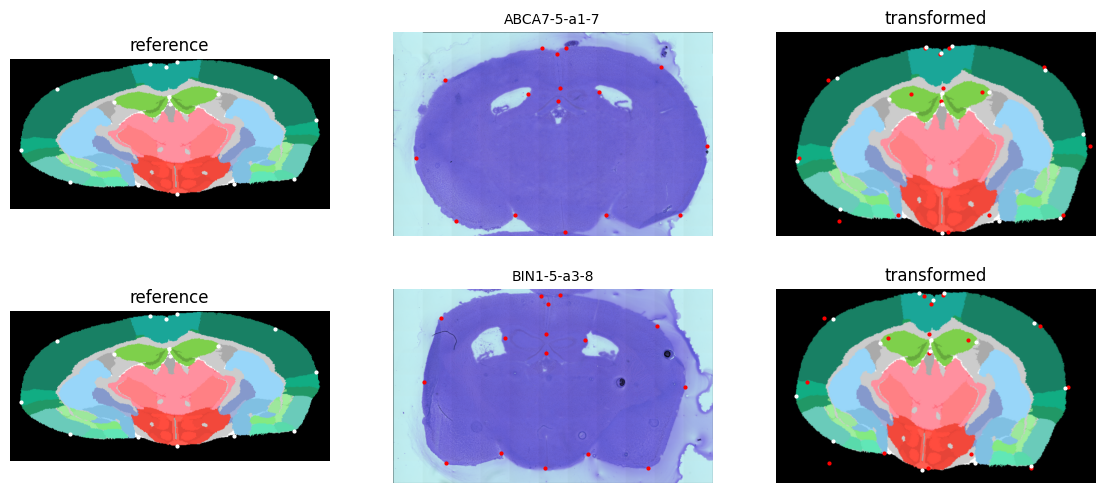

In [4]:
# STEP 3 - Display  results of transformation and registration
import re
plt.figure(figsize=(14,nrow*3))
for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed) in enumerate(zip(samples,
                                                                                                               coord_sets, landmarks_transformed, query_images, images_transformed)):
# for i, (landmark, img, img_transformed, landmark_transformed) in enumerate(zip(landmarks[1:], images[1:], images_transformed, landmarks_transformed)):
    # reference image
    plt.subplot(nrow,3,3*i+1)
    plt.title('reference')
    plt.imshow(reference_image)
    plt.plot(reference_landmarks.iloc[0,:].filter(regex='V').values,
             reference_landmarks.iloc[1,:].filter(regex='V').values,'bo',c="white",markersize=2)
    plt.axis('off')

    # image to transform
    plt.subplot(nrow,3,3*i+2)
    plt.title(re.sub("_hires.png","",sample), fontsize=10)
    plt.imshow(img)
    plt.plot(query_landmarks.iloc[(2*i),:].filter(regex='V').values,
             query_landmarks.iloc[(2*i+1),:].filter(regex='V').values,'ro',markersize=2)
    plt.axis('off')

    # transformed image
    plt.subplot(nrow,3,3*i+3)
    plt.title('transformed')
    plt.imshow(img_transformed)
    plt.plot(query_landmarks.iloc[(2*i),:].filter(regex='V').values,
             query_landmarks.iloc[(2*i+1),:].filter(regex='V').values,'ro',markersize=2)
    # plt.plot(query_landmarks.iloc[(2*i),1:n_features].values,query_landmarks.iloc[(2*i+1),1:n_features].values,'ro',markersize=2)
    plt.plot(pd.DataFrame(landmark_transformed).iloc[:,0],
             pd.DataFrame(landmark_transformed).iloc[:,1],'o',c="white",markersize=2)
    plt.axis('off')
    
    # fig.set_size_inches(10, 10)
# plt.suptitle(f'Layers {layers_to_align}', y=0.9)
#plt.suptitle(f'Layers {layers_to_align}')
##plt.show()
plt.savefig(out_dir+'Spatial_Registration_v4_0.pdf', dpi =400)


In [5]:
# STEP 4 - Link each spot to an annotation region

# create region maps for Visium images
for name, image in zip(samples,images_transformed):
    im = Image.fromarray(image)
    im.save(out_dir+name+"_hires_region.png")
    #plt.savefig(dir+"/"+title, dpi=my_dpi)
    
# Import color scheme list since each region is associated with a color
#color_scheme = pd.read_csv('reference/Color_Scheme_List.csv')
color_scheme = pd.read_csv(os.path.join(ref_dir, "Color_Scheme_List.csv"))
color_scheme.head(10)


,IDX,R,G,B,A,VIS,IDX.1,LABEL,color_code,gray
0,997,255,255,255,1,1,1,root,#FFFFFF,254.9745
1,500,31,157,90,1,1,1,Somatomotor areas,#1F9D5A,119.3229
2,453,24,128,100,1,1,1,Somatosensory areas,#188064,96.9016
3,677,17,173,131,1,1,1,Visceral area,#11AD83,126.3543
4,95,33,152,102,1,1,1,Agranular insular area,#219866,116.4157
5,254,26,166,152,1,1,1,Retrosplenial area,#1AA698,124.1374
6,22,0,159,172,1,1,1,Posterior parietal association areas,#009FAC,111.4590
7,698,154,210,189,1,1,1,Olfactory areas,#9AD2BD,193.2406
8,961,106,203,186,1,1,1,Piriform area,#6ACBBA,173.9864
9,631,97,231,183,1,1,1,Cortical amygdalar area,#61E7B7,190.9243


In [6]:
# Import spots center coordinates
spots_coords = pd.read_csv(os.path.join(r_dir, 'spots_coords_hi_res.csv'))
spots_coords['imagerow'] = round(spots_coords['imagerow'])
spots_coords['imagecol'] = round(spots_coords['imagecol'])
spots_coords['region'] = "root"
spots_coords[["imagerow", "imagecol"]] = spots_coords[["imagerow", "imagecol"]].astype("int")

# For each image, identify the color/region associated at each spot
for idx in range(len(samples)):
    im = images_transformed[idx].copy()
    mask = spots_coords['slice'] == samples[idx]
    
    for i in spots_coords[mask].index:
        row = spots_coords.at[i, 'imagerow']
        col = spots_coords.at[i, 'imagecol']
        height, width = im.shape[:2]

        if 0 <= row < height and 0 <= col < width:
            color = im[row, col]
            if not np.array_equal(color, [0, 0, 0]):
                match = color_scheme['LABEL'][
                    (color_scheme['R'] == color[0]) &
                    (color_scheme['G'] == color[1]) &
                    (color_scheme['B'] == color[2])
                ]
                if not match.empty:
                    spots_coords.at[i, 'region'] = match.values[0]


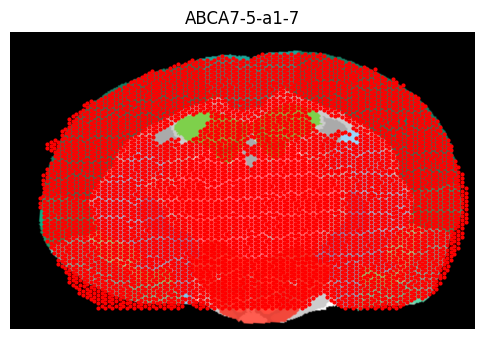

In [7]:
idx = 0  # ABCA7-5-a1-7
plt.figure(figsize=(6,10))
plt.imshow(images_transformed[idx])
plt.plot(spots_coords.imagecol[spots_coords['slice'] == samples[idx]],
         spots_coords.imagerow[spots_coords['slice'] == samples[idx]], 'ro', markersize=2)
plt.title(samples[idx])
plt.axis("off")
plt.show()


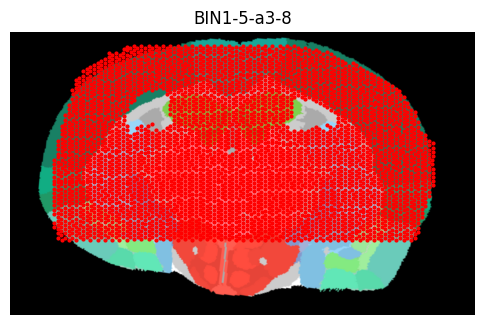

In [13]:
idx = 1  # BIN1-5-a3-8
plt.figure(figsize=(6,10))
plt.imshow(images_transformed[idx])
plt.plot(spots_coords.imagecol[spots_coords['slice'] == samples[idx]],
         spots_coords.imagerow[spots_coords['slice'] == samples[idx]], 'ro', markersize=2)
plt.title(samples[idx])
plt.axis("off")
plt.show()


In [14]:
spots_coords.to_csv(out_dir + "spots_coords_regions.csv") 